train: (891, 12) test: (418, 11)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            37

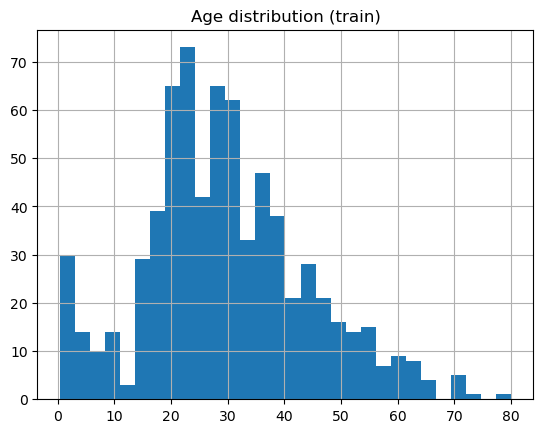


[LogisticRegression] CV Accuracy: mean=0.8249, std=0.0111, scores=[0.838  0.8202 0.809  0.8202 0.8371]

[RandomForest] CV Accuracy: mean=0.8058, std=0.0330, scores=[0.8659 0.7753 0.7809 0.7921 0.8146]

[GradientBoosting] CV Accuracy: mean=0.8361, std=0.0159, scores=[0.8659 0.8258 0.8202 0.8371 0.8315]
Fitting 5 folds for each of 25 candidates, totalling 125 fits

[Best RF params]
{'model__n_estimators': 800, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': None, 'model__max_depth': None}
Best CV Accuracy: 0.8473

Saved: C:\Users\a0916\OneDrive\바탕 화면\DartB_Titanic\submission_from_model.csv
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1


In [3]:
# Titanic 생존자 분석/예측 (Windows 경로 버전)
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance


# -----------------------------
# 0) 데이터 로드 (사용자 제공 경로)
# -----------------------------
TRAIN_PATH = r"C:\Users\a0916\OneDrive\바탕 화면\DartB_Titanic\train.csv"
TEST_PATH  = r"C:\Users\a0916\OneDrive\바탕 화면\DartB_Titanic\test.csv"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print("train:", train.shape, "test:", test.shape)
print(train.head())
print(test.head())

OUTPUT_DIR = Path(TRAIN_PATH).parent  # 같은 폴더에 결과 저장


# -----------------------------
# 1) EDA (기초 확인)
# -----------------------------
def missing_table(df: pd.DataFrame) -> pd.DataFrame:
    miss_cnt = df.isna().sum()
    miss_rate = (miss_cnt / len(df)).round(4)
    out = pd.DataFrame({"missing_count": miss_cnt, "missing_rate": miss_rate})
    return out.sort_values("missing_rate", ascending=False)

print("\n[Train Missing]")
print(missing_table(train))

print("\n[Test Missing]")
print(missing_table(test))

print("\n[Target distribution: Survived]")
print(train["Survived"].value_counts(normalize=True))

for col in ["Sex", "Pclass", "Embarked"]:
    tmp = train.groupby(col)["Survived"].mean().sort_values(ascending=False)
    print(f"\n[Survival rate by {col}]")
    print(tmp)

plt.figure()
train["Age"].hist(bins=30)
plt.title("Age distribution (train)")
plt.show()


# -----------------------------
# 2) 피처 엔지니어링 Transformer
# -----------------------------
class TitanicFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.ticket_count_ = None

    @staticmethod
    def _extract_title(name: str) -> str:
        m = re.search(r",\s*([A-Za-z]+)\.", str(name))
        return m.group(1) if m else "Unknown"

    @staticmethod
    def _simplify_title(title: str) -> str:
        title = str(title)
        rare = {"Lady", "Countess", "Capt", "Col", "Don", "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona"}
        if title in rare:
            return "Rare"
        if title in {"Mlle", "Ms"}:
            return "Miss"
        if title == "Mme":
            return "Mrs"
        return title

    def fit(self, X, y=None):
        X_ = X.copy()
        self.ticket_count_ = X_["Ticket"].value_counts()
        return self

    def transform(self, X):
        X_ = X.copy()

        X_["Title"] = X_["Name"].apply(self._extract_title).apply(self._simplify_title)

        X_["FamilySize"] = X_["SibSp"].fillna(0) + X_["Parch"].fillna(0) + 1
        X_["IsAlone"] = (X_["FamilySize"] == 1).astype(int)

        X_["CabinDeck"] = X_["Cabin"].fillna("U").astype(str).str[0]

        X_["TicketGroupSize"] = X_["Ticket"].map(self.ticket_count_).fillna(1).astype(int)

        X_["FarePerPerson"] = X_["Fare"] / X_["FamilySize"].replace(0, 1)
        X_["LogFare"] = np.log1p(X_["Fare"])

        drop_cols = ["Name", "Ticket", "Cabin"]
        X_ = X_.drop(columns=[c for c in drop_cols if c in X_.columns])

        return X_


# -----------------------------
# 3) 전처리 파이프라인
# -----------------------------
TARGET = "Survived"
X = train.drop(columns=[TARGET])
y = train[TARGET]

numeric_features = ["Age", "SibSp", "Parch", "Fare", "FamilySize", "TicketGroupSize", "FarePerPerson", "LogFare"]
categorical_features = ["Pclass", "Sex", "Embarked", "Title", "CabinDeck"]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)


# -----------------------------
# 4) 모델 평가 (Stratified K-Fold)
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(model, name="model"):
    pipe = Pipeline(steps=[
        ("feat", TitanicFeatureEngineer()),
        ("prep", preprocess),
        ("model", model),
    ])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
    print(f"\n[{name}] CV Accuracy: mean={scores.mean():.4f}, std={scores.std():.4f}, scores={np.round(scores,4)}")
    return pipe

lr_pipe = evaluate_model(LogisticRegression(max_iter=1000), "LogisticRegression")
rf_pipe = evaluate_model(RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1), "RandomForest")
gb_pipe = evaluate_model(GradientBoostingClassifier(random_state=42), "GradientBoosting")


# -----------------------------
# 5) RandomForest 튜닝(예시)
# -----------------------------
rf_tune_pipe = Pipeline(steps=[
    ("feat", TitanicFeatureEngineer()),
    ("prep", preprocess),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1)),
])

param_dist = {
    "model__n_estimators": [200, 400, 800],
    "model__max_depth": [None, 4, 6, 8, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None],
}

search = RandomizedSearchCV(
    rf_tune_pipe,
    param_distributions=param_dist,
    n_iter=25,
    scoring="accuracy",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X, y)
print("\n[Best RF params]")
print(search.best_params_)
print(f"Best CV Accuracy: {search.best_score_:.4f}")

best_model = search.best_estimator_


# -----------------------------
# 6) 최종 학습 → 예측 → 제출파일 저장
# -----------------------------
best_model.fit(X, y)
test_pred = best_model.predict(test)

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": test_pred.astype(int),
})

out_path = OUTPUT_DIR / "submission_from_model.csv"
submission.to_csv(out_path, index=False, encoding="utf-8-sig")
print(f"\nSaved: {out_path}")
print(submission.head())



plt.show()


[Top 20 important features (One-Hot 이후 기준)]
            feature  importance_mean  importance_std
18         Title_Mr         0.184961        0.008999
10         Pclass_3         0.079461        0.006391
6     FarePerPerson         0.066293        0.007867
0               Age         0.041227        0.005077
20       Title_Rare         0.013318        0.001526
30      CabinDeck_U         0.006135        0.001780
7           LogFare         0.005088        0.002385
5   TicketGroupSize         0.004789        0.002441
3              Fare         0.004564        0.002371
17       Title_Miss         0.004265        0.000935
23      CabinDeck_B         0.002993        0.000529
4        FamilySize         0.002768        0.002044
13       Embarked_C         0.001945        0.001120
15       Embarked_S         0.001272        0.001351
22      CabinDeck_A         0.001122        0.000000
26      CabinDeck_E         0.001048        0.000280
16     Title_Master         0.000374        0.000785
2

C:\Users\a0916\AppData\Local\Temp\ipykernel_28208\3249158934.py:57: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\a0916\AppData\Local\Temp\ipykernel_28208\3249158934.py:57: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\a0916\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\a0916\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


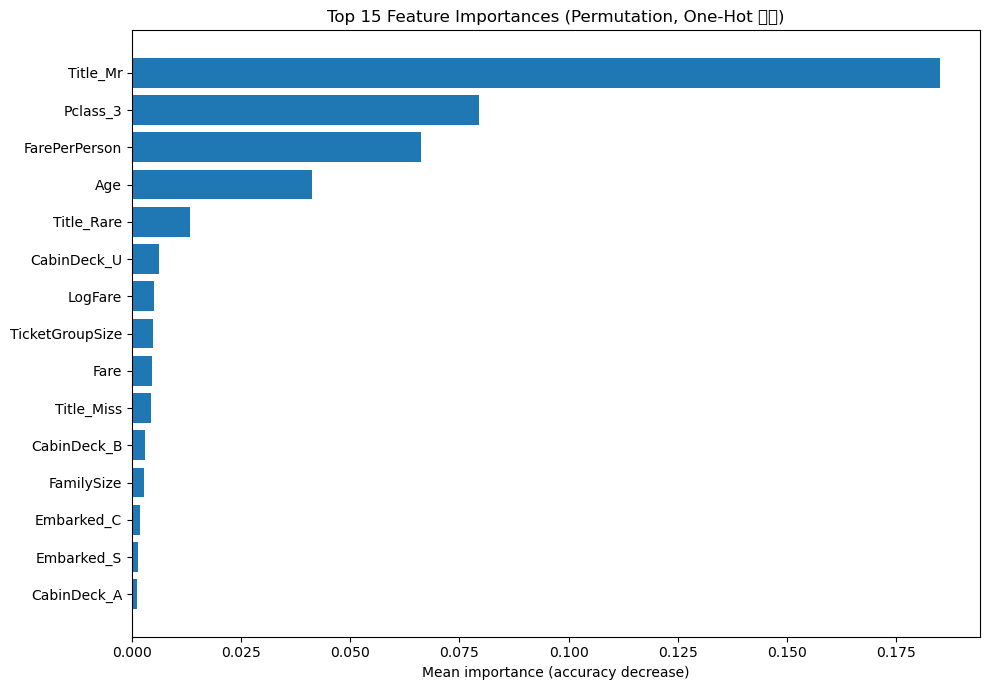

In [4]:
# -----------------------------
# 7) 해석: Permutation Importance (원핫 이후 피처 기준)  ✅
# -----------------------------
from sklearn.inspection import permutation_importance
import scipy.sparse as sp
import pandas as pd
import matplotlib.pyplot as plt

# 파이프라인에서 단계 꺼내기
feat_step = best_model.named_steps["feat"]
prep_step = best_model.named_steps["prep"]
clf       = best_model.named_steps["model"]

# 1) Feature Engineering 적용 (DataFrame 유지)
X_fe = feat_step.transform(X)

# 2) 전처리(원핫 포함) 적용
X_tr = prep_step.transform(X_fe)

# 3) sparse면 dense로 변환 (트리 모델에서 안전하게)
if sp.issparse(X_tr):
    X_tr = X_tr.toarray()

# 4) 변환 후 피처 이름 만들기
#    (numeric_features, categorical_features는 위에서 정의한 그대로 사용)
ohe = prep_step.named_transformers_["cat"].named_steps["onehot"]
feat_names = numeric_features + list(ohe.get_feature_names_out(categorical_features))

# 안전 체크: 길이 불일치하면 바로 알려주기
if X_tr.shape[1] != len(feat_names):
    raise ValueError(f"피처 개수 불일치: X_tr={X_tr.shape[1]}, feat_names={len(feat_names)}")

# 5) 분류기만 대상으로 permutation importance 계산
perm = permutation_importance(
    clf, X_tr, y,
    n_repeats=15,
    random_state=42,
    scoring="accuracy",
    n_jobs=-1
)

imp = pd.DataFrame({
    "feature": feat_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("\n[Top 20 important features (One-Hot 이후 기준)]")
print(imp.head(20))

# 6) 시각화
plt.figure(figsize=(10, 7))
topk = imp.head(15).iloc[::-1]
plt.barh(topk["feature"], topk["importance_mean"])
plt.title("Top 15 Feature Importances (Permutation, One-Hot 기준)")
plt.xlabel("Mean importance (accuracy decrease)")
plt.tight_layout()
plt.show()

train: (891, 12) test: (418, 11)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            37

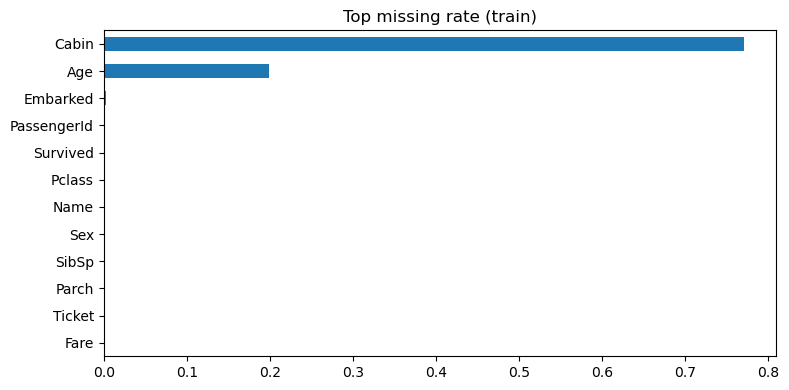


[Skewness (train numeric)]
     col  skewness
1   Fare  4.787317
2  SibSp  3.695352
3  Parch  2.749117
0    Age  0.389108


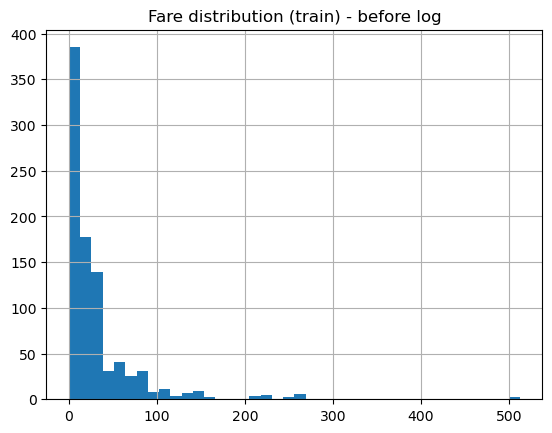


Numeric features: ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'TicketGroupSize', 'FarePerPerson', 'LogFare']
Categorical features: ['Pclass', 'Sex', 'Embarked', 'Title', 'CabinDeck']

=== CV baseline ===
[LogisticRegression] CV acc mean=0.8260, std=0.0109, scores=[0.838  0.8202 0.809  0.8258 0.8371]
[RandomForest] CV acc mean=0.8035, std=0.0262, scores=[0.8492 0.7753 0.7809 0.8034 0.809 ]
[GradientBoosting] CV acc mean=0.8361, std=0.0170, scores=[0.8603 0.8202 0.8146 0.8483 0.8371]

=== RandomForest RandomizedSearchCV ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV: 0.84509446990145
Best params: {'model__n_estimators': 500, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': None, 'model__max_depth': 8, 'feat__fare_clip_q': 0.98}

[Holdout Classification Report]
              precision    recall  f1-score   support

           0     0.8190    0.8636    0.8407       110
           1     0.7619    0.6957    0.7273

C:\Users\a0916\AppData\Local\Temp\ipykernel_4552\1480184915.py:373: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\a0916\AppData\Local\Temp\ipykernel_4552\1480184915.py:373: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\a0916\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\a0916\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


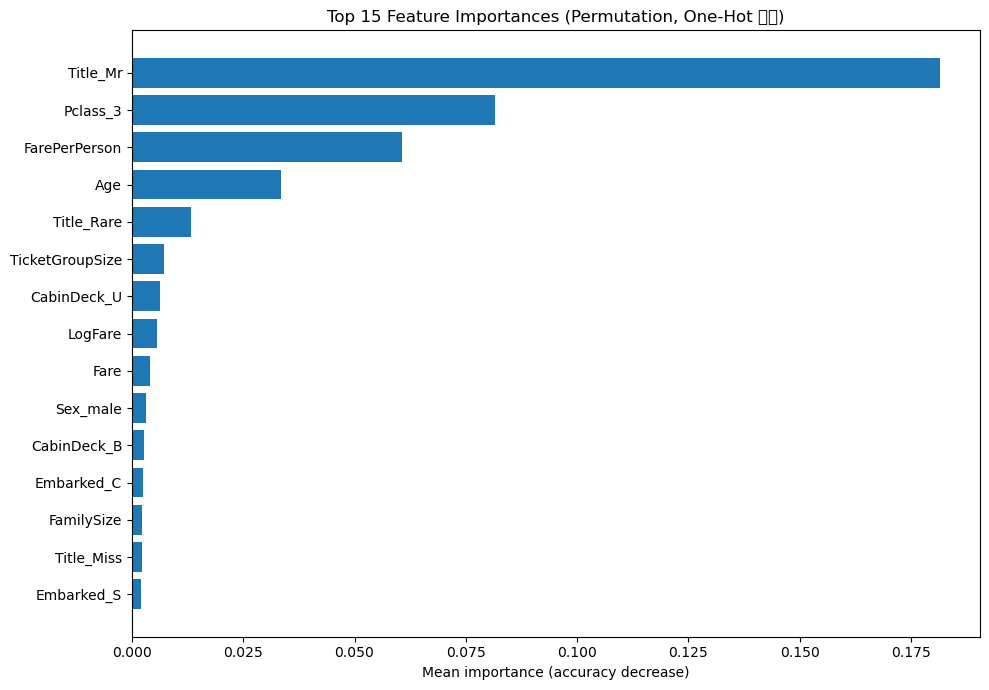

In [1]:
# =========================================================
# Titanic ML Modeling Template (Guideline-based)
# - 결측치 처리, 인코딩, 스케일링, 왜도/이상치, 피처 생성/선택
# - Stratified K-Fold, 하이퍼파라미터 튜닝, 평가 지표
# - train 학습 -> test 예측 -> submission.csv 저장
# =========================================================
# Guideline reference:
# 결측치/인코딩/스케일링/왜도/이상치/피처/분할/모델/평가/과적합 방지 :contentReference[oaicite:3]{index=3} :contentReference[oaicite:4]{index=4}

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

from scipy import sparse


# -----------------------------
# 0) 데이터 로드 (Windows 경로)
# -----------------------------
TRAIN_PATH = r"C:\Users\a0916\OneDrive\바탕 화면\DartB_Titanic\train.csv"
TEST_PATH  = r"C:\Users\a0916\OneDrive\바탕 화면\DartB_Titanic\test.csv"

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)
OUTPUT_DIR = Path(TRAIN_PATH).parent

print("train:", train.shape, "test:", test.shape)
print(train.head())


# -----------------------------
# 1) EDA(최소): 결측치 / 기본 생존률 확인
#    - 결측치 확인 및 시각화 권장 :contentReference[oaicite:5]{index=5}
# -----------------------------
def missing_table(df):
    m = df.isna().sum().sort_values(ascending=False)
    return pd.DataFrame({"missing_count": m, "missing_rate": (m / len(df)).round(4)})

print("\n[Missing - train]")
print(missing_table(train).head(15))

print("\n[Target rate]")
print(train["Survived"].value_counts(normalize=True))

# 결측치 bar plot (간단)
plt.figure(figsize=(8,4))
missing_table(train)["missing_rate"].head(15).iloc[::-1].plot(kind="barh")
plt.title("Top missing rate (train)")
plt.tight_layout()
plt.show()

# 왜도 확인(예: Fare) :contentReference[oaicite:6]{index=6}
def skew_summary(df, cols):
    out = []
    for c in cols:
        if c in df.columns:
            out.append((c, float(df[c].dropna().skew())))
    return pd.DataFrame(out, columns=["col", "skewness"]).sort_values("skewness", ascending=False)

print("\n[Skewness (train numeric)]")
print(skew_summary(train, ["Age","Fare","SibSp","Parch"]))

plt.figure()
train["Fare"].dropna().hist(bins=40)
plt.title("Fare distribution (train) - before log")
plt.show()


# -----------------------------
# 2) 피처 엔지니어링 + (왜도/이상치 처리 포함)
#    - Feature Engineering & Selection 권장 :contentReference[oaicite:7]{index=7}
#    - 왜도: 로그 변환 :contentReference[oaicite:8]{index=8}
#    - 이상치: 기준 제시 후 처리 :contentReference[oaicite:9]{index=9}
# -----------------------------
class TitanicFeatureEngineer(BaseEstimator, TransformerMixin):
    """
    - Title: Name에서 추출 (사회적 지위/성별/연령 신호)
    - FamilySize, IsAlone: 가족 동승 효과
    - CabinDeck: Cabin 첫 글자(결측은 U)
    - TicketGroupSize: 같은 티켓의 동행 규모(학습 데이터 기준 카운트 저장)
    - FarePerPerson: 요금/가족 규모
    - LogFare: Fare 왜도 보정
    - Fare clipping: outlier 완화(학습 데이터의 99% 분위수 기반)
    """
    def __init__(self, fare_clip_q=0.99):
        self.ticket_count_ = None
        self.fare_clip_value_ = None
        self.fare_clip_q = fare_clip_q

    @staticmethod
    def _extract_title(name: str) -> str:
        m = re.search(r",\s*([A-Za-z]+)\.", str(name))
        return m.group(1) if m else "Unknown"

    @staticmethod
    def _simplify_title(title: str) -> str:
        title = str(title)
        rare = {"Lady","Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"}
        if title in rare:
            return "Rare"
        if title in {"Mlle", "Ms"}:
            return "Miss"
        if title == "Mme":
            return "Mrs"
        return title

    def fit(self, X, y=None):
        X_ = X.copy()
        if "Ticket" in X_.columns:
            self.ticket_count_ = X_["Ticket"].value_counts()
        # Fare outlier clipping 기준(학습 데이터에서만 산출)
        if "Fare" in X_.columns:
            self.fare_clip_value_ = float(X_["Fare"].dropna().quantile(self.fare_clip_q))
        return self

    def transform(self, X):
        X_ = X.copy()

        # ----- Outlier handling (Fare clipping) -----
        # 이상치 처리 여부/기준 제시 권장 :contentReference[oaicite:10]{index=10}
        if "Fare" in X_.columns and self.fare_clip_value_ is not None:
            X_["Fare"] = X_["Fare"].clip(upper=self.fare_clip_value_)

        # ----- Title -----
        if "Name" in X_.columns:
            X_["Title"] = X_["Name"].apply(self._extract_title).apply(self._simplify_title)
        else:
            X_["Title"] = "Unknown"

        # ----- Family -----
        X_["FamilySize"] = X_.get("SibSp", 0).fillna(0) + X_.get("Parch", 0).fillna(0) + 1
        X_["IsAlone"] = (X_["FamilySize"] == 1).astype(int)

        # ----- CabinDeck -----
        if "Cabin" in X_.columns:
            X_["CabinDeck"] = X_["Cabin"].fillna("U").astype(str).str[0]
        else:
            X_["CabinDeck"] = "U"

        # ----- TicketGroupSize (train 기준 카운트) -----
        if "Ticket" in X_.columns and self.ticket_count_ is not None:
            X_["TicketGroupSize"] = X_["Ticket"].map(self.ticket_count_).fillna(1).astype(int)
        else:
            X_["TicketGroupSize"] = 1

        # ----- Fare-based -----
        X_["FarePerPerson"] = X_.get("Fare", 0) / X_["FamilySize"].replace(0, 1)
        # 왜도 처리: Log 변환 :contentReference[oaicite:11]{index=11}
        X_["LogFare"] = np.log1p(X_.get("Fare", 0).fillna(0))

        # ----- Feature selection (drop text/high-card columns) -----
        # 불필요한 변수 제거(과적합 방지) :contentReference[oaicite:12]{index=12}
        X_ = X_.drop(columns=["Name", "Ticket", "Cabin"], errors="ignore")

        return X_


# -----------------------------
# 3) 전처리: 결측치 대체 + 인코딩 + 스케일링
#    - 결측치 대체 필요 :contentReference[oaicite:13]{index=13}
#    - One-Hot / Label / Target encoding 고려 :contentReference[oaicite:14]{index=14}
#    - 스케일링 논의 :contentReference[oaicite:15]{index=15}
# -----------------------------
TARGET = "Survived"
X_raw = train.drop(columns=[TARGET])
y = train[TARGET]

# 피처엔지니어링 후 실제 컬럼을 보고 존재하는 것만 사용(에러 방지)
_fe_tmp = TitanicFeatureEngineer().fit(X_raw).transform(X_raw)
all_cols = _fe_tmp.columns.tolist()

numeric_candidates = ["Age","SibSp","Parch","Fare","FamilySize","IsAlone","TicketGroupSize","FarePerPerson","LogFare"]
categorical_candidates = ["Pclass","Sex","Embarked","Title","CabinDeck"]

numeric_features = [c for c in numeric_candidates if c in all_cols]
categorical_features = [c for c in categorical_candidates if c in all_cols]

print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)

# sklearn 버전에 따라 sparse_output / sparse 파라미터명이 다를 수 있어 안전하게 처리
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)  # 최신
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)         # 구버전

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   # 결측치 대체(중앙값) :contentReference[oaicite:16]{index=16}
    ("scaler", StandardScaler()),                    # 스케일링 :contentReference[oaicite:17]{index=17}
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),  # 결측치 대체(최빈값)
    ("onehot", ohe),                                       # 인코딩(One-Hot) :contentReference[oaicite:18]{index=18}
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)


# -----------------------------
# 4) 데이터 분할 & 교차검증(과적합 방지)
#    - Stratified K-Fold 권장 :contentReference[oaicite:19]{index=19}
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_cv(pipe, name):
    scores = cross_val_score(pipe, X_raw, y, cv=cv, scoring="accuracy")
    print(f"[{name}] CV acc mean={scores.mean():.4f}, std={scores.std():.4f}, scores={np.round(scores,4)}")
    return scores.mean()


# -----------------------------
# 5) 모델 선택(선형/비선형) + 튜닝
#    - 모델 선택 논리 :contentReference[oaicite:20]{index=20}
#    - 하이퍼파라미터 튜닝 :contentReference[oaicite:21]{index=21}
# -----------------------------
lr_pipe = Pipeline([
    ("feat", TitanicFeatureEngineer()),
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=3000, C=1.0, penalty="l2"))  # 정규화(L2)로 과적합 완화 :contentReference[oaicite:22]{index=22}
])

rf_pipe = Pipeline([
    ("feat", TitanicFeatureEngineer()),
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=500, random_state=42, n_jobs=-1,
        max_depth=None, min_samples_leaf=1
    ))
])

gb_pipe = Pipeline([
    ("feat", TitanicFeatureEngineer()),
    ("prep", preprocess),
    ("model", GradientBoostingClassifier(random_state=42))
])

print("\n=== CV baseline ===")
evaluate_cv(lr_pipe, "LogisticRegression")
evaluate_cv(rf_pipe, "RandomForest")
evaluate_cv(gb_pipe, "GradientBoosting")

print("\n=== RandomForest RandomizedSearchCV ===")
rf_tune_pipe = Pipeline([
    ("feat", TitanicFeatureEngineer()),
    ("prep", preprocess),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_dist = {
    "feat__fare_clip_q": [0.98, 0.99, 0.995],      # 이상치 완화 강도도 튜닝 대상
    "model__n_estimators": [300, 500, 800, 1200],
    "model__max_depth": [None, 4, 6, 8, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None],
}

search = RandomizedSearchCV(
    rf_tune_pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring="accuracy",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_raw, y)
print("Best CV:", search.best_score_)
print("Best params:", search.best_params_)

best_model = search.best_estimator_


# -----------------------------
# 6) 홀드아웃 평가(Accuracy/Precision/Recall/F1) + 혼동행렬
#    - 평가 지표 선택 및 설명 :contentReference[oaicite:23]{index=23}
# -----------------------------
X_tr, X_va, y_tr, y_va = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

best_model.fit(X_tr, y_tr)
va_pred = best_model.predict(X_va)

print("\n[Holdout Classification Report]")
print(classification_report(y_va, va_pred, digits=4))
print("[Confusion Matrix]\n", confusion_matrix(y_va, va_pred))


# -----------------------------
# 7) 최종 학습 -> test 예측 -> submission.csv 저장
# -----------------------------
best_model.fit(X_raw, y)
test_pred = best_model.predict(test)

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": test_pred.astype(int)
})
out_path = OUTPUT_DIR / "submission.csv"
submission.to_csv(out_path, index=False, encoding="utf-8-sig")
print("\nSaved:", out_path)
print(submission.head())


# -----------------------------
# 8) (요청한 2번) 원-핫 이후 피처 기준 해석: Permutation Importance
#    - “왜 성능이 나왔는지” 이해가 중요 :contentReference[oaicite:24]{index=24}
# -----------------------------
feat_step = best_model.named_steps["feat"]
prep_step = best_model.named_steps["prep"]
clf       = best_model.named_steps["model"]

# 변환
X_fe = feat_step.transform(X_raw)
X_tr_all = prep_step.transform(X_fe)
if sparse.issparse(X_tr_all):
    X_tr_all = X_tr_all.toarray()

# 피처 이름
ohe_step = prep_step.named_transformers_["cat"].named_steps["onehot"]
onehot_names = list(ohe_step.get_feature_names_out(categorical_features))
feat_names = numeric_features + onehot_names

if X_tr_all.shape[1] != len(feat_names):
    raise ValueError(f"피처 개수 불일치: X_tr={X_tr_all.shape[1]}, feat_names={len(feat_names)}")

perm = permutation_importance(
    clf, X_tr_all, y,
    n_repeats=15,
    random_state=42,
    scoring="accuracy",
    n_jobs=-1
)

imp = pd.DataFrame({
    "feature": feat_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("\n[Top 20 important features (One-Hot 이후 기준)]")
print(imp.head(20))

plt.figure(figsize=(10, 7))
topk = imp.head(15).iloc[::-1]
plt.barh(topk["feature"], topk["importance_mean"])
plt.title("Top 15 Feature Importances (Permutation, One-Hot 기준)")
plt.xlabel("Mean importance (accuracy decrease)")
plt.tight_layout()
plt.show()

In [2]:
import re
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

from scipy import sparse


# =========================
# 0) 데이터 로드 (너의 경로)
# =========================
TRAIN_PATH = r"C:\Users\a0916\OneDrive\바탕 화면\DartB_Titanic\train.csv"
TEST_PATH  = r"C:\Users\a0916\OneDrive\바탕 화면\DartB_Titanic\test.csv"

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)
OUTPUT_DIR = Path(TRAIN_PATH).parent

TARGET = "Survived"
X_raw = train.drop(columns=[TARGET])
y = train[TARGET]


# =========================
# 1) Feature Engineering (+ outlier clip + skew 처리)
# =========================
class TitanicFeatureEngineer(BaseEstimator, TransformerMixin):
    """
    - Title: Name에서 추출 (Mr/Mrs/Miss/Master/Rare)
    - FamilySize, IsAlone
    - CabinDeck: Cabin 첫 글자, 결측은 U
    - TicketGroupSize: train 기준 ticket 카운트
    - FarePerPerson, LogFare
    - Fare clip: 상위 분위수로 이상치 완화(옵션)
    """
    def __init__(self, fare_clip_q=0.99):
        self.fare_clip_q = fare_clip_q
        self.ticket_count_ = None
        self.fare_clip_value_ = None

    @staticmethod
    def _extract_title(name: str) -> str:
        m = re.search(r",\s*([A-Za-z]+)\.", str(name))
        return m.group(1) if m else "Unknown"

    @staticmethod
    def _simplify_title(title: str) -> str:
        rare = {"Lady","Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"}
        if title in rare:
            return "Rare"
        if title in {"Mlle", "Ms"}:
            return "Miss"
        if title == "Mme":
            return "Mrs"
        return title

    def fit(self, X, y=None):
        X_ = X.copy()
        self.ticket_count_ = X_["Ticket"].value_counts() if "Ticket" in X_.columns else None
        if "Fare" in X_.columns:
            self.fare_clip_value_ = float(X_["Fare"].dropna().quantile(self.fare_clip_q))
        return self

    def transform(self, X):
        X_ = X.copy()

        # Fare outlier clip
        if "Fare" in X_.columns and self.fare_clip_value_ is not None:
            X_["Fare"] = X_["Fare"].clip(upper=self.fare_clip_value_)

        # Title
        X_["Title"] = X_["Name"].apply(self._extract_title).apply(self._simplify_title)

        # Family
        X_["FamilySize"] = X_["SibSp"].fillna(0) + X_["Parch"].fillna(0) + 1
        X_["IsAlone"] = (X_["FamilySize"] == 1).astype(int)

        # CabinDeck
        X_["CabinDeck"] = X_["Cabin"].fillna("U").astype(str).str[0]

        # Ticket group
        if self.ticket_count_ is not None:
            X_["TicketGroupSize"] = X_["Ticket"].map(self.ticket_count_).fillna(1).astype(int)
        else:
            X_["TicketGroupSize"] = 1

        # Fare-based
        X_["FarePerPerson"] = X_["Fare"] / X_["FamilySize"].replace(0, 1)
        X_["LogFare"] = np.log1p(X_["Fare"].fillna(0))

        # Drop raw text / high-card columns
        X_ = X_.drop(columns=["Name","Ticket","Cabin"], errors="ignore")
        return X_


# =========================
# 2) Preprocess: impute + scale + onehot
# =========================
# sklearn 버전 호환 (sparse_output / sparse)
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

# 피처엔지니어링 후 실제 컬럼을 보고 존재하는 것만 사용(안전)
tmp_cols = TitanicFeatureEngineer().fit(X_raw).transform(X_raw).columns.tolist()

numeric_candidates = ["Age","SibSp","Parch","Fare","FamilySize","IsAlone","TicketGroupSize","FarePerPerson","LogFare"]
categorical_candidates = ["Pclass","Sex","Embarked","Title","CabinDeck"]

numeric_features = [c for c in numeric_candidates if c in tmp_cols]
categorical_features = [c for c in categorical_candidates if c in tmp_cols]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe),
])

preprocess = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])


# =========================
# 3) CV 평가(베이스라인/비선형 비교)
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_eval(pipe, name):
    scores = cross_val_score(pipe, X_raw, y, cv=cv, scoring="accuracy")
    print(f"[{name}] CV acc mean={scores.mean():.4f} std={scores.std():.4f} scores={np.round(scores,4)}")
    return scores.mean()

lr_pipe = Pipeline([
    ("feat", TitanicFeatureEngineer()),
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=3000, C=1.0, penalty="l2")),
])

rf_pipe = Pipeline([
    ("feat", TitanicFeatureEngineer()),
    ("prep", preprocess),
    ("model", RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)),
])

gb_pipe = Pipeline([
    ("feat", TitanicFeatureEngineer()),
    ("prep", preprocess),
    ("model", GradientBoostingClassifier(random_state=42)),
])

print("=== CV Baselines ===")
cv_eval(lr_pipe, "LogisticRegression (interpretable baseline)")
cv_eval(rf_pipe, "RandomForest")
cv_eval(gb_pipe, "GradientBoosting")


# =========================
# 4) 튜닝(RandomizedSearch) - RandomForest 예시
# =========================
tune_pipe = Pipeline([
    ("feat", TitanicFeatureEngineer()),
    ("prep", preprocess),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1)),
])

param_dist = {
    "feat__fare_clip_q": [0.98, 0.99, 0.995],
    "model__n_estimators": [300, 500, 800, 1200],
    "model__max_depth": [None, 4, 6, 8, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None],
}

search = RandomizedSearchCV(
    tune_pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring="accuracy",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_raw, y)
print("Best CV:", search.best_score_)
print("Best params:", search.best_params_)

best_model = search.best_estimator_


# =========================
# 5) Holdout 리포트(Accuracy 외에 Precision/Recall/F1 확인)
# =========================
X_tr, X_va, y_tr, y_va = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)
best_model.fit(X_tr, y_tr)
va_pred = best_model.predict(X_va)

print("\n[Holdout Classification Report]")
print(classification_report(y_va, va_pred, digits=4))
print("[Confusion Matrix]\n", confusion_matrix(y_va, va_pred))


# =========================
# 6) 최종 학습 -> test 예측 -> submission.csv
# =========================
best_model.fit(X_raw, y)
test_pred = best_model.predict(test)

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": test_pred.astype(int)
})
out_path = OUTPUT_DIR / "submission.csv"
submission.to_csv(out_path, index=False, encoding="utf-8-sig")
print("\nSaved:", out_path)
print(submission.head())


# =========================
# 7) (해석) One-Hot 이후 피처 기준 Permutation Importance
# =========================
feat_step = best_model.named_steps["feat"]
prep_step = best_model.named_steps["prep"]
clf = best_model.named_steps["model"]

X_fe = feat_step.transform(X_raw)
X_enc = prep_step.transform(X_fe)
if sparse.issparse(X_enc):
    X_enc = X_enc.toarray()

ohe_step = prep_step.named_transformers_["cat"].named_steps["onehot"]
feat_names = numeric_features + list(ohe_step.get_feature_names_out(categorical_features))

perm = permutation_importance(
    clf, X_enc, y,
    n_repeats=15, random_state=42,
    scoring="accuracy", n_jobs=-1
)

imp = pd.DataFrame({
    "feature": feat_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

print("\n[Top 20 important features (One-Hot 기준)]")
print(imp.head(20))

=== CV Baselines ===
[LogisticRegression (interpretable baseline)] CV acc mean=0.8260 std=0.0109 scores=[0.838  0.8202 0.809  0.8258 0.8371]
[RandomForest] CV acc mean=0.8035 std=0.0262 scores=[0.8492 0.7753 0.7809 0.8034 0.809 ]
[GradientBoosting] CV acc mean=0.8361 std=0.0170 scores=[0.8603 0.8202 0.8146 0.8483 0.8371]
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV: 0.84509446990145
Best params: {'model__n_estimators': 500, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': None, 'model__max_depth': 8, 'feat__fare_clip_q': 0.98}

[Holdout Classification Report]
              precision    recall  f1-score   support

           0     0.8190    0.8636    0.8407       110
           1     0.7619    0.6957    0.7273        69

    accuracy                         0.7989       179
   macro avg     0.7904    0.7796    0.7840       179
weighted avg     0.7970    0.7989    0.7970       179

[Confusion Matrix]
 [[95 15]
 [21 48]]

Saved: